In [92]:
import pandas as pd
import matplotlib.pyplot as plt


In [93]:
df=pd.read_csv("Mall_Customers.csv")

In [94]:
df.describe(include = 'object')

,Gender
count,200
unique,2
top,Female
freq,112


In [95]:
x = df.loc[:, ['Spending Score (1-100)', 'Annual Income (k$)']].values


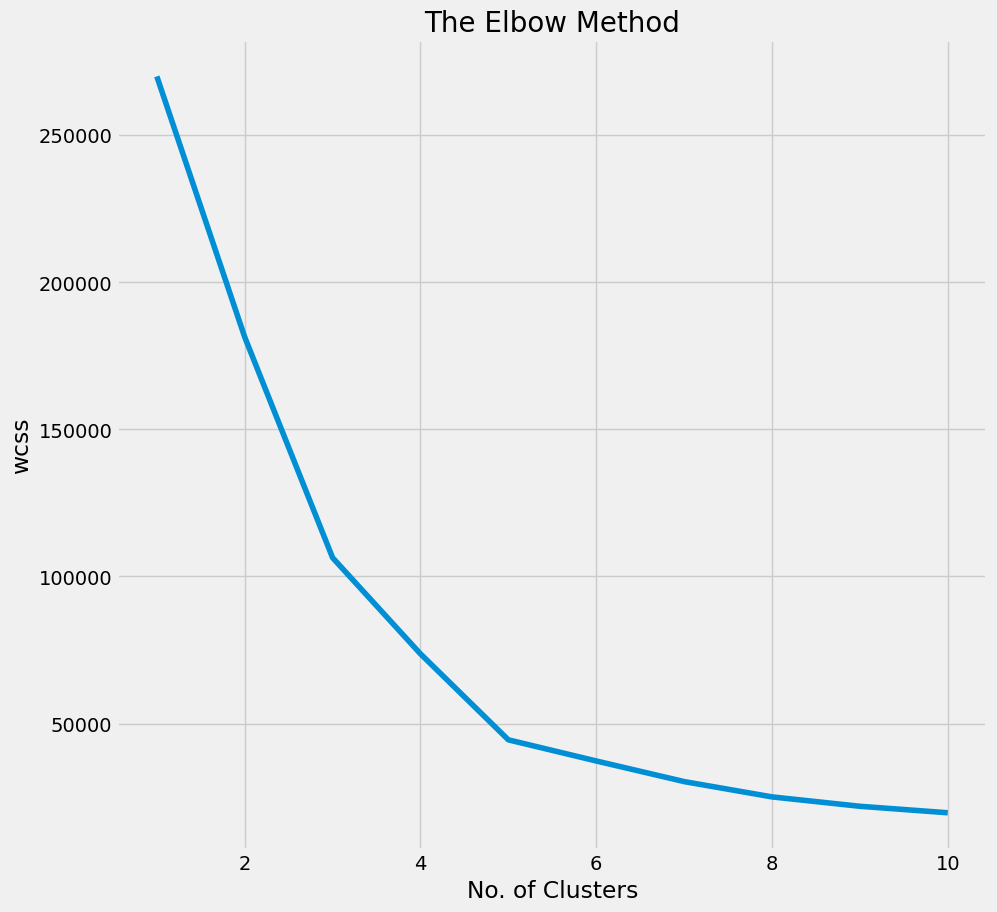

In [96]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method', fontsize = 20)
plt.xlabel('No. of Clusters')
plt.ylabel('wcss')
plt.show()

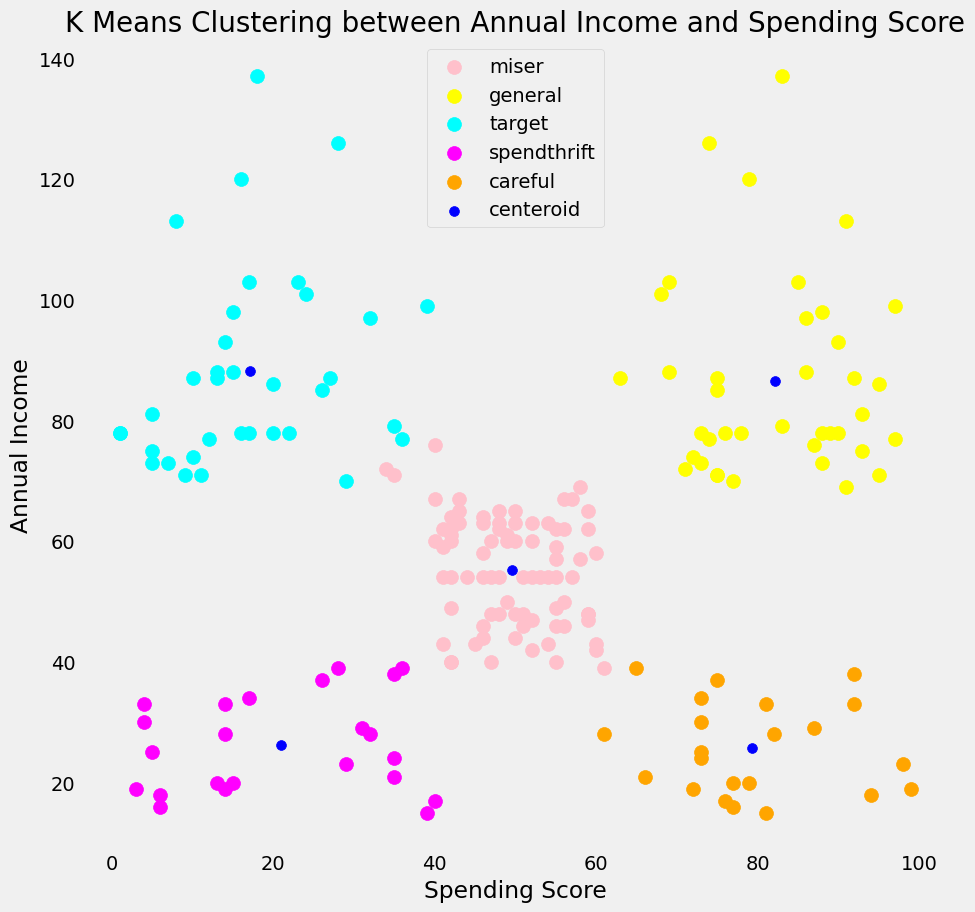

In [97]:




km = KMeans(n_clusters = 5, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_means = km.fit_predict(x)

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s = 100, c = 'pink', label = 'miser')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s = 100, c = 'yellow', label = 'general')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s = 100, c = 'cyan', label = 'target')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s = 100, c = 'magenta', label = 'spendthrift')
plt.scatter(x[y_means == 4, 0], x[y_means == 4, 1], s = 100, c = 'orange', label = 'careful')
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:, 1], s = 50, c = 'blue' , label = 'centeroid')


plt.style.use('fivethirtyeight')
plt.title('K Means Clustering between Annual Income and Spending Score', fontsize = 20)
plt.xlabel('Spending Score')
plt.ylabel('Annual Income')
plt.legend()
plt.grid()
plt.show()

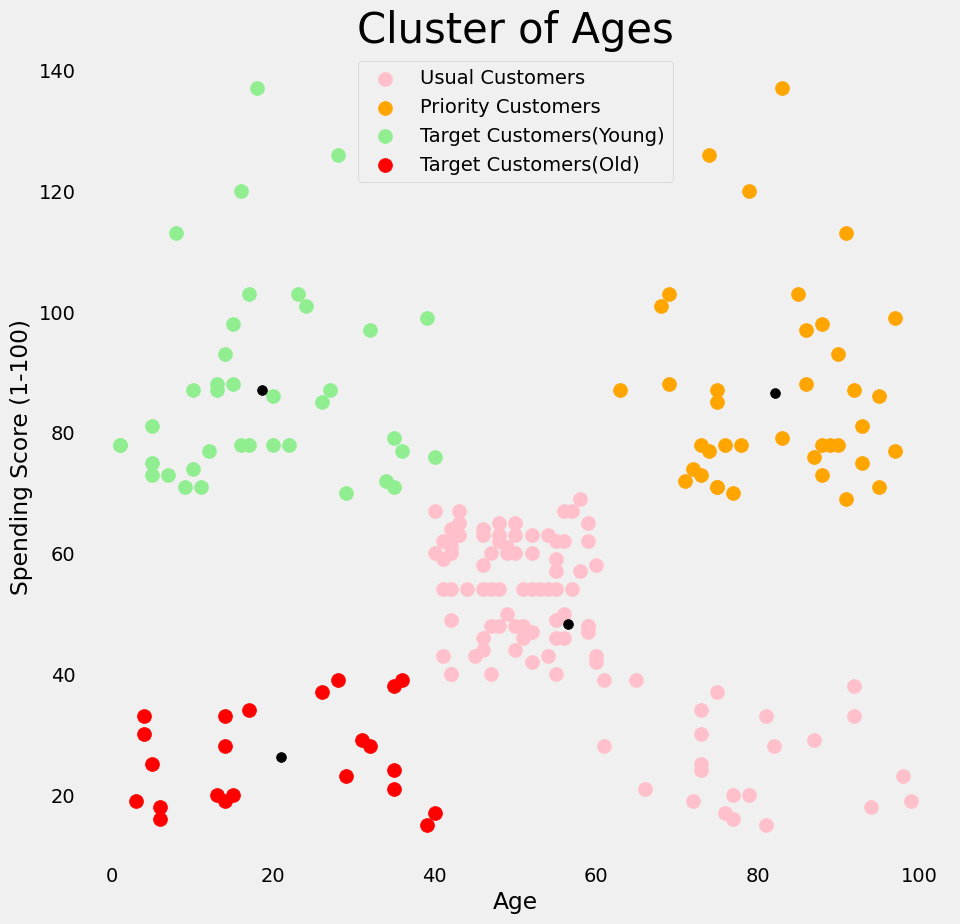

In [98]:
kmeans = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
ymeans = kmeans.fit_predict(x)

plt.rcParams['figure.figsize'] = (10, 10)
plt.title('Cluster of Ages', fontsize = 30)

plt.scatter(x[ymeans == 0, 0], x[ymeans == 0, 1], s = 100, c = 'pink', label = 'Usual Customers' )
plt.scatter(x[ymeans == 1, 0], x[ymeans == 1, 1], s = 100, c = 'orange', label = 'Priority Customers')
plt.scatter(x[ymeans == 2, 0], x[ymeans == 2, 1], s = 100, c = 'lightgreen', label = 'Target Customers(Young)')
plt.scatter(x[ymeans == 3, 0], x[ymeans == 3, 1], s = 100, c = 'red', label = 'Target Customers(Old)')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 50, c = 'black')

plt.style.use('fivethirtyeight')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid()
plt.show()

In [99]:
df = pd.read_csv('Mall_Customers.csv')
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

avg_scores = {}

print(f'Feature matrix shape: {X_scaled.shape}')

Feature matrix shape: (200, 2)


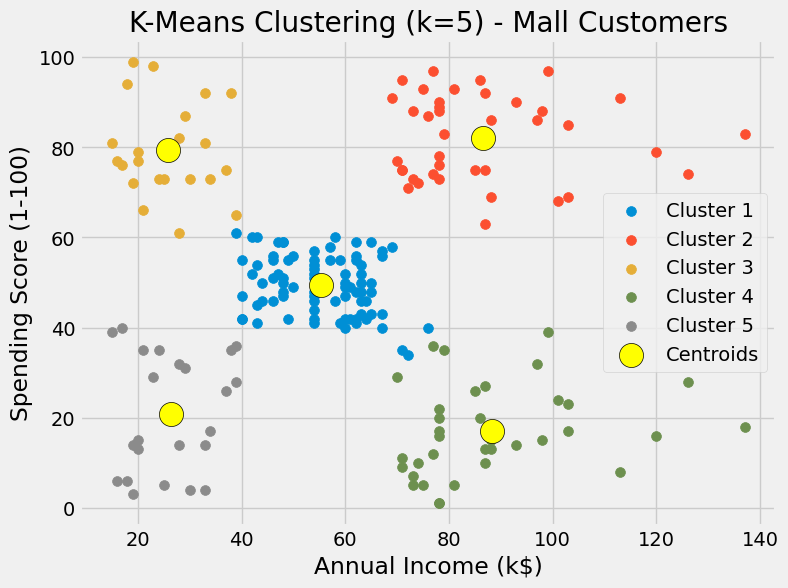

In [100]:


X = df.iloc[:, [3, 4]].values

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=50, label='Cluster 5')

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='yellow',
    marker='o',
    edgecolor='black',
    label='Centroids'
)

plt.title('K-Means Clustering (k=5) - Mall Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True)

plt.show()

In [101]:
from sklearn.metrics import silhouette_samples,silhouette_score
import matplotlib.cm as cm


In [102]:
def plot_silhouette(n_clusters):
    """Run KMeans with n_clusters and display the silhouette + scatter plots."""
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.2, 1])
    ax1.set_ylim([0, len(X_scaled) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    avg_scores[n_clusters] = silhouette_avg
    print(f'n_clusters = {n_clusters}  |  avg silhouette score = {silhouette_avg:.4f}')

    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_vals = sample_silhouette_values[cluster_labels == i]
        ith_vals.sort()
        size_i = ith_vals.shape[0]
        y_upper = y_lower + size_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper), 0, ith_vals,
            facecolor=color, edgecolor=color, alpha=0.7
        )
        ax1.text(-0.05, y_lower + 0.5 * size_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title('Silhouette plot for each cluster')
    ax1.set_xlabel('Silhouette coefficient')
    ax1.set_ylabel('Cluster label')
    ax1.axvline(x=silhouette_avg, color='red', linestyle='--',
                label=f'Avg = {silhouette_avg:.3f}')
    ax1.legend(loc='upper right')
    ax1.set_yticks([])
    ax1.set_xticks([-0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X[:, 0], X[:, 1],
        marker='.', s=60, lw=0, alpha=0.8, c=colors, edgecolor='k'
    )

    centers_original = scaler.inverse_transform(clusterer.cluster_centers_)
    ax2.scatter(
        centers_original[:, 0], centers_original[:, 1],
        marker='o', c='white', alpha=1, s=250, edgecolor='k', zorder=5
    )
    for i, c in enumerate(centers_original):
        ax2.scatter(c[0], c[1], marker=f'${i}$', alpha=1, s=60, edgecolor='k', zorder=6)

    ax2.set_title('Clustered Mall Customers')
    ax2.set_xlabel('Annual Income (k$)')
    ax2.set_ylabel('Spending Score (1-100)')

    plt.suptitle(
        f'Silhouette Analysis — KMeans on Mall Customers (n_clusters = {n_clusters})',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

n_clusters = 2  |  avg silhouette score = 0.3973


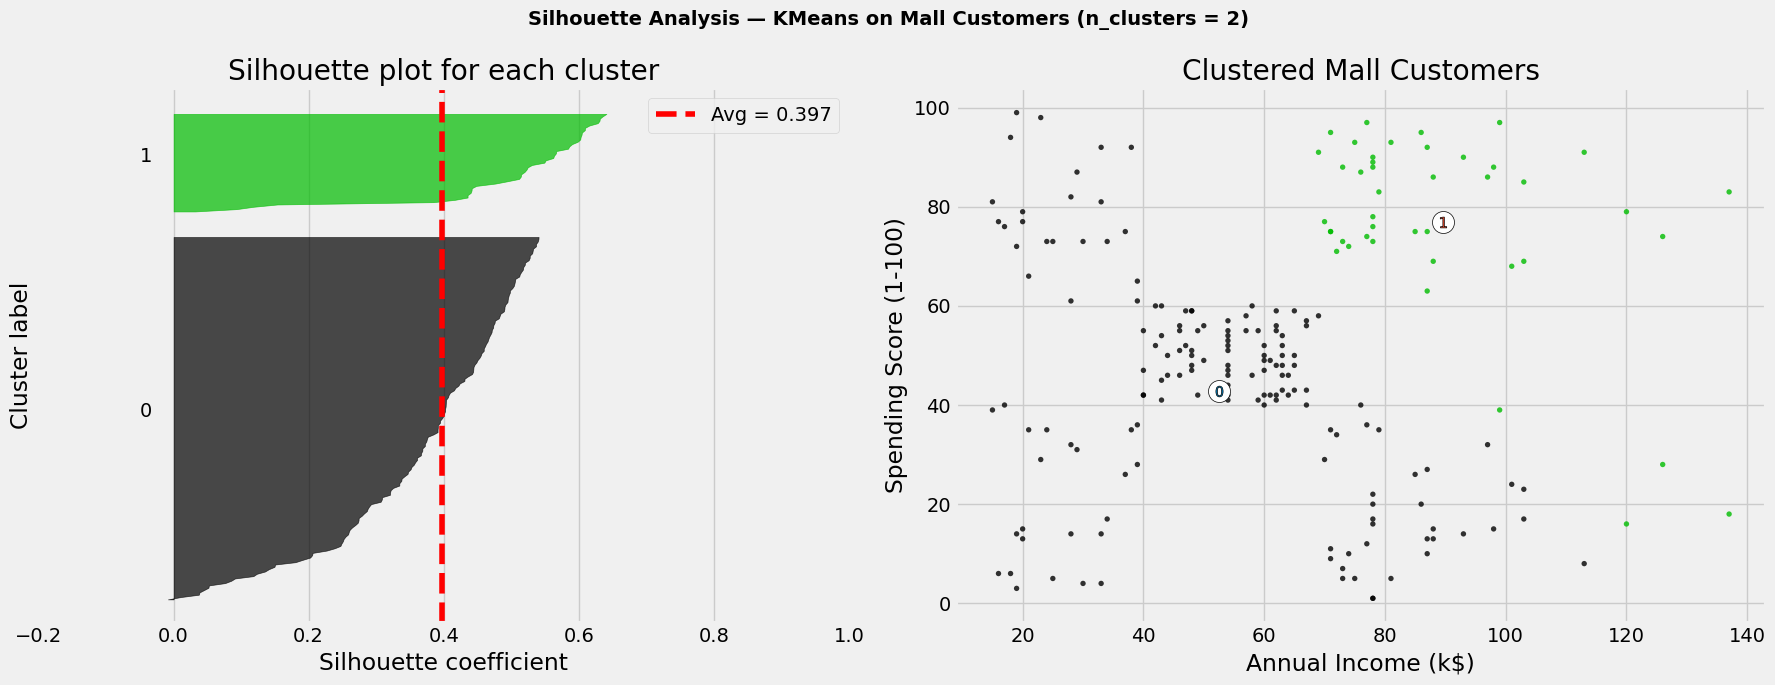

n_clusters = 3  |  avg silhouette score = 0.4666


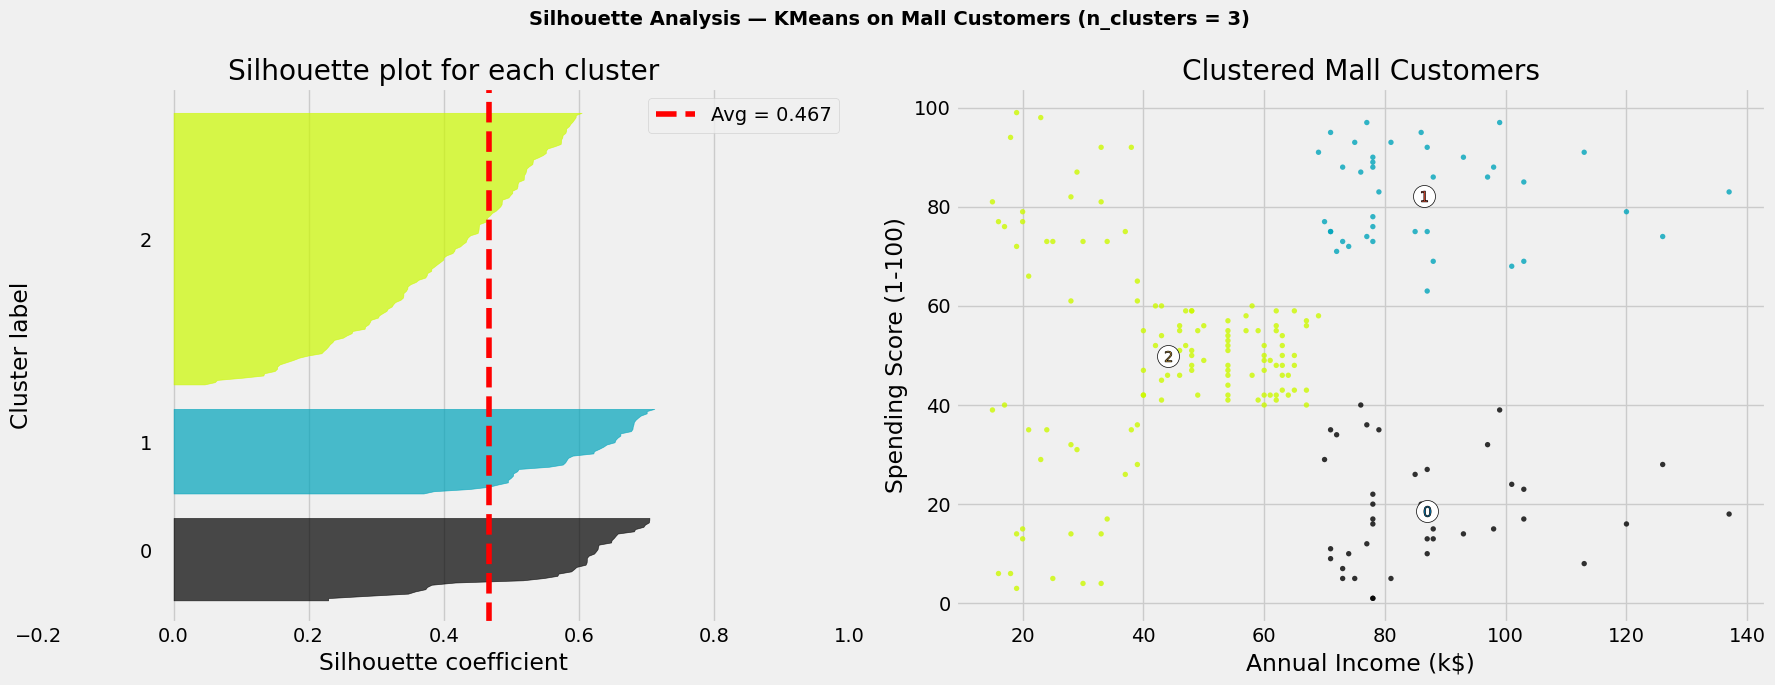

n_clusters = 4  |  avg silhouette score = 0.4943


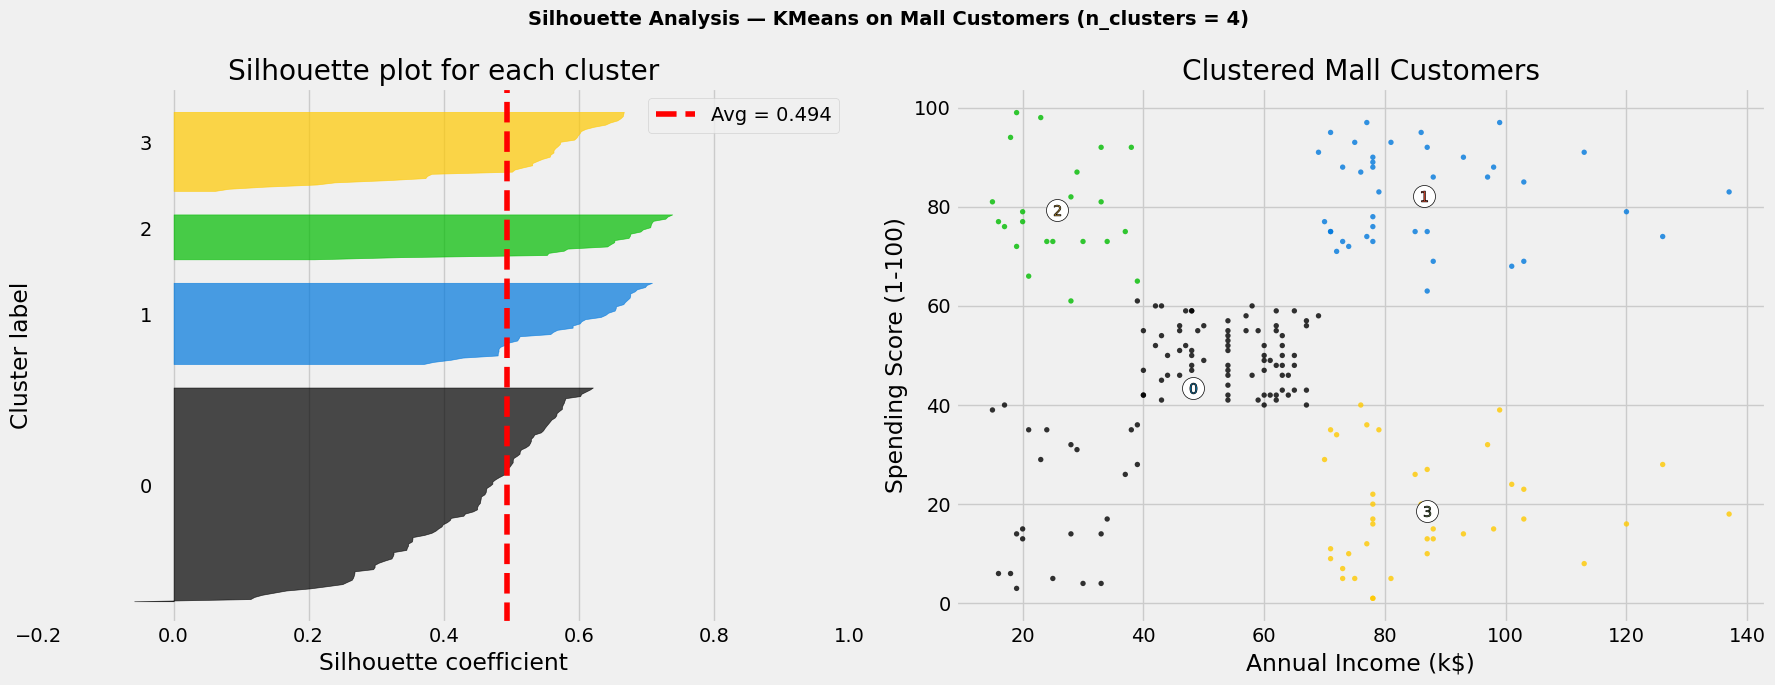

n_clusters = 5  |  avg silhouette score = 0.5547


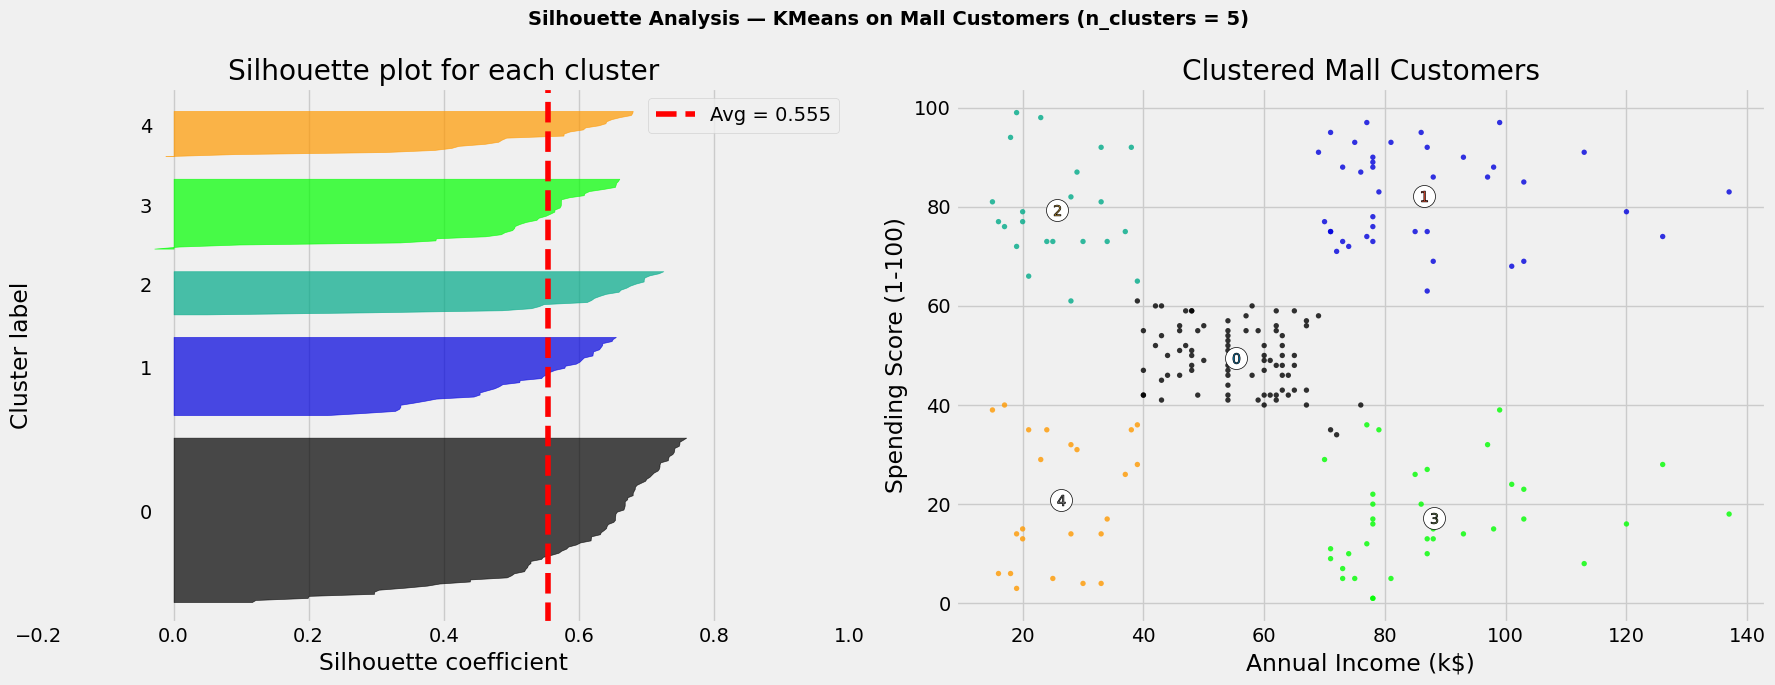

n_clusters = 6  |  avg silhouette score = 0.5138


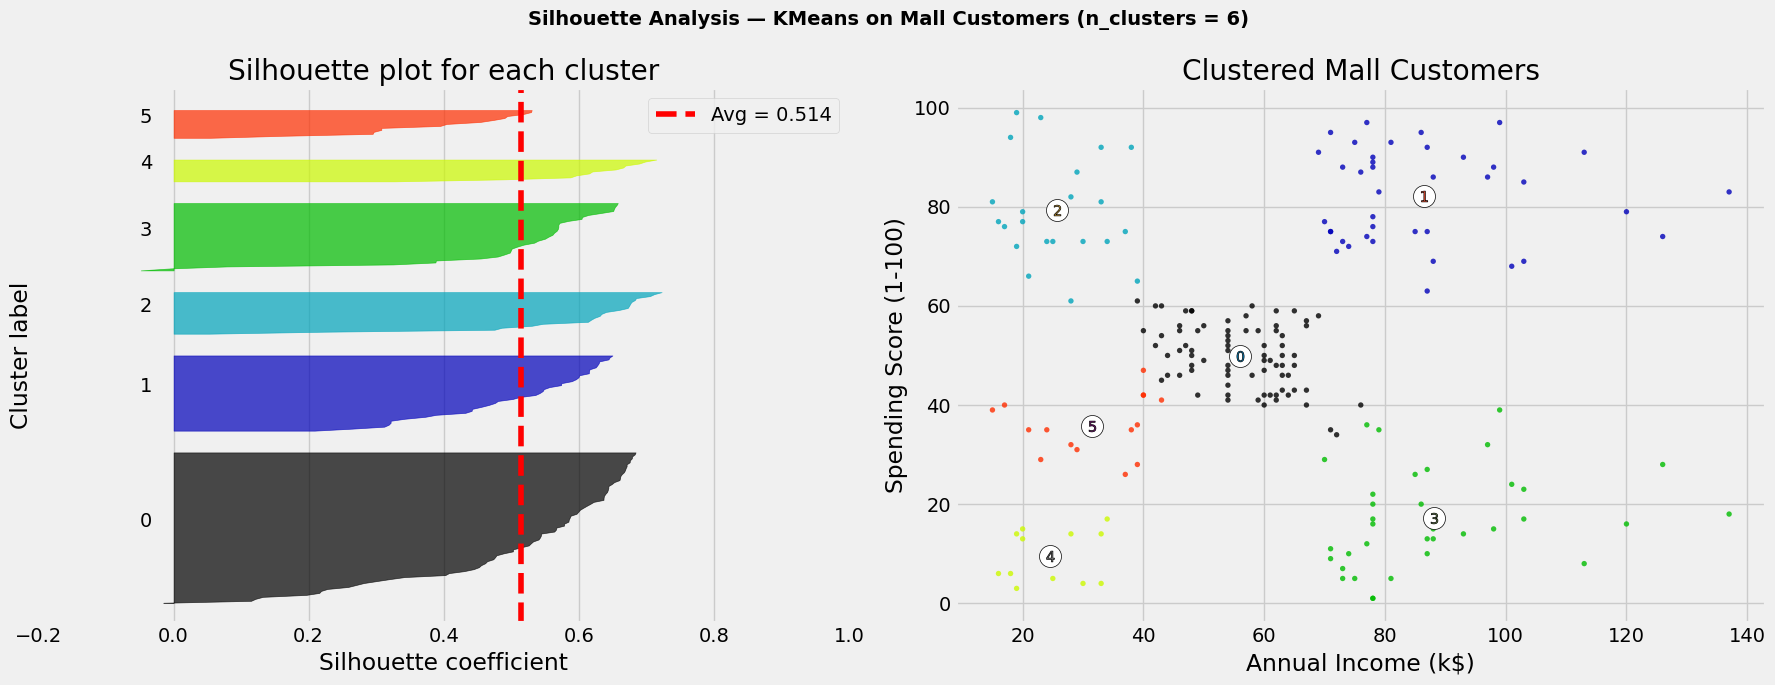

In [103]:
plot_silhouette(2)
plot_silhouette(3)
plot_silhouette(4)
plot_silhouette(5)
plot_silhouette(6)

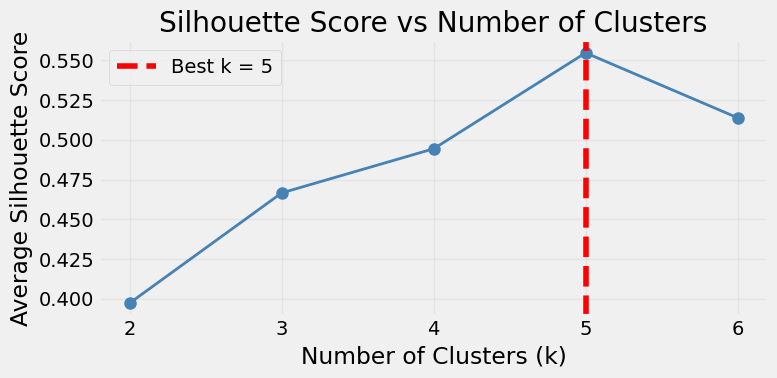


 Optimal number of clusters: k = 5  (score = 0.5547)


In [104]:
ks = sorted(avg_scores.keys())
scores = [avg_scores[k] for k in ks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ks, scores, 'o-', color='steelblue', linewidth=2, markersize=8)
best_k = ks[np.argmax(scores)]
ax.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Average Silhouette Score')
ax.set_title('Silhouette Score vs Number of Clusters')
ax.set_xticks(ks)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n Optimal number of clusters: k = {best_k}  (score = {max(scores):.4f})')